# Predicción secuencial de perímetros de incendios — modelo final

Implementa la metodología de `latex.txt`. No usar `demo.ipynb` como referencia.

## 0. Setup

In [1]:
import torch, random, json, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely import wkt
from shapely.geometry import Polygon, shape
from shapely.ops import unary_union
from shapely.validation import make_valid
from shapely.affinity import scale, translate
from affine import Affine
import rasterio.features
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

def set_seed(seed=42, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

set_seed(42, deterministic=True)
DEVICE = get_device()
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
print("device:", DEVICE)

device: mps


## 1. Carga y partición

In [2]:
DATA_PATH = "Datos Procesados/final/transitions_master.parquet"
df = pd.read_parquet(DATA_PATH)

train = df[df["split"] == "train"].copy()
val   = df[df["split"] == "val"].copy()
test  = df[df["split"] == "test"].copy()

assert len(df) == 1171,    f"Esperado 1171, obtenido {len(df)}"
assert len(train) == 825,  f"Esperado 825, obtenido {len(train)}"
assert len(val)   == 159,  f"Esperado 159, obtenido {len(val)}"
assert len(test)  == 187,  f"Esperado 187, obtenido {len(test)}"

print(f"Transiciones totales: {len(df)}")
print(f"  train={len(train)}  val={len(val)}  test={len(test)}")

Transiciones totales: 1171
  train=825  val=159  test=187


## 2. Preprocesamiento

Imputación (mediana) y estandarización ajustadas **exclusivamente sobre train**, aplicadas sin reajuste en val y test.

In [3]:
X_cols = [c for c in df.columns if c.startswith("t_")]
assert len(X_cols) == 117, f"Esperado 117, obtenido {len(X_cols)}"
print(f"Features totales: {len(X_cols)}")

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_imp = pd.DataFrame(imputer.fit_transform(train[X_cols]), columns=X_cols)
X_val_imp   = pd.DataFrame(imputer.transform(val[X_cols]),       columns=X_cols)
X_test_imp  = pd.DataFrame(imputer.transform(test[X_cols]),      columns=X_cols)

X_train_sc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_val_sc   = scaler.transform(X_val_imp).astype(np.float32)
X_test_sc  = scaler.transform(X_test_imp).astype(np.float32)

assert np.isnan(X_train_sc).sum() == 0, "NaN en X_train_sc — revisar imputer"
assert np.isnan(X_val_sc).sum()   == 0, "NaN en X_val_sc"
assert np.isnan(X_test_sc).sum()  == 0, "NaN en X_test_sc"
print("Preprocesamiento OK — sin NaN en ningún split")

Features totales: 117
Preprocesamiento OK — sin NaN en ningún split


## 3. Baseline de identidad

Predice $\hat{P}_{t+1} = P_t$. La mediana global de IoU entre pasos consecutivos es 0.246; la media en val resulta ≈ 0.28.

In [4]:
def polygonal_only(geom):
    """Extrae solo componentes poligonales tras make_valid; devuelve None si no queda nada."""
    if geom is None or geom.is_empty:
        return None
    geom = make_valid(geom)
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    if geom.geom_type == "GeometryCollection":
        parts = [g for g in geom.geoms
                 if g.geom_type in ("Polygon", "MultiPolygon") and not g.is_empty]
        return unary_union(parts) if parts else None
    return None

def poly_iou(a, b):
    if a is None or b is None or a.is_empty or b.is_empty:
        return 0.0
    inter = a.intersection(b).area
    union = a.union(b).area
    return inter / union if union > 0 else 0.0

def poly_dice(a, b):
    if a is None or b is None or a.is_empty or b.is_empty:
        return 0.0
    inter = a.intersection(b).area
    denom = a.area + b.area
    return 2 * inter / denom if denom > 0 else 0.0

def identity_metrics(split_df):
    ious, dices = [], []
    n_total = 0
    n_invalid = 0
    for _, row in split_df.iterrows():
        n_total += 1
        pt  = polygonal_only(wkt.loads(row["geometry_t_wkt"]))
        pt1 = polygonal_only(wkt.loads(row["geometry_t1_wkt"]))
        if pt is None or pt1 is None:
            n_invalid += 1
            ious.append(0.0)
            dices.append(0.0)
            continue
        ious.append(poly_iou(pt, pt1))
        dices.append(poly_dice(pt, pt1))
    return {
        "poly_iou": np.mean(ious),
        "poly_dice": np.mean(dices),
        "n_total": n_total,
        "n_invalid": n_invalid,
    }

id_train = identity_metrics(train)
id_val   = identity_metrics(val)
id_test  = identity_metrics(test)

print(f"Identidad — train: {id_train}")
print(f"Identidad — val:   {id_val}")
print(f"Identidad — test:  {id_test}")

Identidad — train: {'poly_iou': np.float64(0.2785758334162082), 'poly_dice': np.float64(0.36476592775162), 'n_total': 825, 'n_invalid': 0}
Identidad — val:   {'poly_iou': np.float64(0.2830740738687731), 'poly_dice': np.float64(0.36452846292017654), 'n_total': 159, 'n_invalid': 0}
Identidad — test:  {'poly_iou': np.float64(0.28536175207997894), 'poly_dice': np.float64(0.36598285201150405), 'n_total': 187, 'n_invalid': 0}


## 4. Baseline Random Forest

`MultiOutputRegressor(RandomForestRegressor)` predice [área_ha, centroid_x, centroid_y, perimeter_m] de $P_{t+1}$.  
El polígono se reconstruye usando **solo área y centroide**: homotecia de factor $s = \sqrt{A_{pred}/A_t}$ centrada en el centroide actual, seguida de traslación al centroide predicho.  
El perímetro predicho no interviene en la reconstrucción; se reporta como métrica diagnóstica.

In [5]:
def extract_targets(split_df):
    # col 3: perimeter_m se predice para referencia diagnóstica; no se usa en reconstruct_polygon
    geoms = split_df["geometry_t1_wkt"].apply(wkt.loads)
    return np.column_stack([
        geoms.apply(lambda g: g.area / 1e4),    # area_ha
        geoms.apply(lambda g: g.centroid.x),    # centroid_x UTM
        geoms.apply(lambda g: g.centroid.y),    # centroid_y UTM
        geoms.apply(lambda g: g.length),        # perimeter_m (diagnóstico)
    ])

Y_train = extract_targets(train)
Y_val   = extract_targets(val)
Y_test  = extract_targets(test)

rf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
)
rf.fit(X_train_sc, Y_train)
print("RF entrenado")

RF entrenado


In [6]:
def reconstruct_polygon(P_t, pred_area_ha, pred_cx, pred_cy):
    a_t = P_t.area
    if a_t <= 0:
        return P_t
    s = np.sqrt(max(pred_area_ha, 1e-6) * 1e4 / a_t)  # clamp: RF puede predecir area <= 0
    c = P_t.centroid
    P_s = scale(P_t, xfact=s, yfact=s, origin=(c.x, c.y))
    c2  = P_s.centroid
    out = translate(P_s, xoff=pred_cx - c2.x, yoff=pred_cy - c2.y)
    return polygonal_only(out) or P_t  # fallback a identidad si la geometria colapsa

def rf_poly_metrics(split_df, X_sc):
    """Reconstruccion usa solo area y centroide (cols 0-2); perimetro predicho es diagnostico."""
    preds = rf.predict(X_sc)
    ious, dices = [], []
    area_errs, centroid_disps, perim_errs = [], [], []
    n_total = 0
    n_invalid = 0
    for i, (_, row) in enumerate(split_df.iterrows()):
        n_total += 1
        pt  = polygonal_only(wkt.loads(row["geometry_t_wkt"]))
        pt1 = polygonal_only(wkt.loads(row["geometry_t1_wkt"]))
        if pt1 is None or pt is None:
            n_invalid += 1
            ious.append(0.0)
            dices.append(0.0)
            if pt1 is not None:
                area_errs.append(pt1.area / 1e4)
                centroid_disps.append(np.nan)
                perim_errs.append(pt1.length)
            else:
                area_errs.append(np.nan)
                centroid_disps.append(np.nan)
                perim_errs.append(np.nan)
            continue
        ph = reconstruct_polygon(pt, preds[i, 0], preds[i, 1], preds[i, 2])
        ious.append(poly_iou(ph, pt1))
        dices.append(poly_dice(ph, pt1))
        area_errs.append(abs(ph.area - pt1.area) / 1e4)
        centroid_disps.append(ph.centroid.distance(pt1.centroid))
        perim_errs.append(abs(ph.length - pt1.length))
    return {
        "poly_iou": np.mean(ious),
        "poly_dice": np.mean(dices),
        "area_err_ha": np.nanmean(area_errs),
        "centroid_disp_m": np.nanmean(centroid_disps),
        "perim_err_m": np.nanmean(perim_errs),
        "n_total": n_total,
        "n_invalid": n_invalid,
    }

rf_val  = rf_poly_metrics(val,  X_val_sc)
rf_test = rf_poly_metrics(test, X_test_sc)
print(f"RF — val:  {rf_val}")
print(f"RF — test: {rf_test}")

RF — val:  {'poly_iou': np.float64(0.09881382665844253), 'poly_dice': np.float64(0.141794642903574), 'area_err_ha': np.float64(58.73707017509983), 'centroid_disp_m': np.float64(1607.0350596251994), 'perim_err_m': np.float64(1414.0984770139871), 'n_total': 159, 'n_invalid': 0}
RF — test: {'poly_iou': np.float64(0.11155293482371216), 'poly_dice': np.float64(0.154927058201205), 'area_err_ha': np.float64(51.27736472391049), 'centroid_disp_m': np.float64(1723.0482169753095), 'perim_err_m': np.float64(1541.630818199573), 'n_total': 187, 'n_invalid': 0}


## 5. U-Net con acondicionamiento ambiental

### 5.1 Dataset y DataLoader

**Crítico**: la ventana raster se deriva únicamente de `P_t.bounds`. Nunca de la unión con `P_{t+1}`.

In [7]:
FEATURE_COLS_20 = [
    "t_area_ha", "t_perimeter_m", "t_compactness", "t_n_vertices",
    "t_bbox_width_m", "t_bbox_height_m",
    "t_srtm_elev_mean_m", "t_srtm_elev_std_m",
    "t_srtm_slope_mean_deg", "t_srtm_slope_max_deg",
    "t_srtm_aspect_sin_mean", "t_srtm_aspect_cos_mean",
    "t_era5_fire_mean_temperature_2m", "t_era5_fire_mean_relative_humidity_2m",
    "t_era5_fire_mean_wind_speed_10m",
    "t_era5_fire_wind_dir_sin_mean", "t_era5_fire_wind_dir_cos_mean",
    "t_era5_fire_dryness_index",
    "t_firms_total_n_10km", "t_firms_viirs_frp_mean_10km",
]

missing = [c for c in FEATURE_COLS_20 if c not in df.columns]
assert not missing, f"Columnas faltantes: {missing}"
print(f"{len(FEATURE_COLS_20)} features ambientales — todas presentes")

# Escalado independiente para las 20 features de la U-Net
feat_imputer = SimpleImputer(strategy="median")
feat_scaler  = StandardScaler()

Xf_train = feat_imputer.fit_transform(train[FEATURE_COLS_20]).astype(np.float32)
Xf_val   = feat_imputer.transform(val[FEATURE_COLS_20]).astype(np.float32)
Xf_test  = feat_imputer.transform(test[FEATURE_COLS_20]).astype(np.float32)

Xf_train = feat_scaler.fit_transform(Xf_train).astype(np.float32)
Xf_val   = feat_scaler.transform(Xf_val).astype(np.float32)
Xf_test  = feat_scaler.transform(Xf_test).astype(np.float32)

# Verificar que la selección de variables no introduce redundancias fuertes.
# La correlación se calcula exclusivamente en train para confirmar que la selección
# fue realizada sin ver val/test.
corr_train = pd.DataFrame(Xf_train, columns=FEATURE_COLS_20).corr().abs()
upper_tri  = corr_train.where(np.triu(np.ones(corr_train.shape), k=1).astype(bool))
strong_pairs = int((upper_tri > 0.90).sum().sum())
print(f"Pares con |r|>0.90 entre las 20 features seleccionadas (calculado en train): {strong_pairs}")

20 features ambientales — todas presentes
Pares con |r|>0.90 entre las 20 features seleccionadas (calculado en train): 10


In [8]:
RASTER_SIZE = 128

# MARGIN: percentil 85 del factor de expansión mínimo para cubrir P_{t+1}.
# Seleccionado por análisis de sensibilidad (sensibilidad_margin.ipynb) sobre
# P80–P99: P85 maximiza val IoU vectorial (0.498) y no presenta contaminación
# de outliers en error de área, a diferencia de P83 (mean 5373 ha) y P90
# (mean 7104 ha). Calculado exclusivamente en train y congelado para val/test.
def required_margin_factor(P_t, P_t1):
    minx, miny, maxx, maxy = P_t.bounds
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    base_side = max(maxx - minx, maxy - miny, 1.0)
    a, b, c, d = P_t1.bounds
    required_half = max(abs(a - cx), abs(c - cx), abs(b - cy), abs(d - cy))
    return max(1.0, 2 * required_half / base_side)

margin_factors = [
    required_margin_factor(
        wkt.loads(row["geometry_t_wkt"]),
        wkt.loads(row["geometry_t1_wkt"])
    )
    for _, row in train.iterrows()
]
MARGIN = float(np.quantile(margin_factors, 0.85))
print(f"MARGIN P85 calculado en train: {MARGIN:.3f}")


def make_window(P_t, size=RASTER_SIZE, margin=MARGIN):
    """Ventana raster cuadrada centrada en P_t. Nunca usa P_{t+1}."""
    minx, miny, maxx, maxy = P_t.bounds
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    side = max(maxx - minx, maxy - miny, 1.0) * margin
    half = side / 2
    bx0, by0 = cx - half, cy - half
    bx1, by1 = cx + half, cy + half
    px = side / size
    transform = Affine(px, 0, bx0, 0, -px, by1)
    return transform, (bx0, by0, bx1, by1)


def target_coverage(split_df, margin=MARGIN):
    from shapely.geometry import box as shapely_box
    covs = []
    for _, row in split_df.iterrows():
        pt  = wkt.loads(row["geometry_t_wkt"])
        pt1 = wkt.loads(row["geometry_t1_wkt"])
        _, bounds = make_window(pt, margin=margin)
        w   = shapely_box(*bounds)
        cov = pt1.intersection(w).area / pt1.area if pt1.area > 0 else 0.0
        covs.append(cov)
    return pd.Series(covs).describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.85, 0.95])

cov_train = target_coverage(train)
cov_val   = target_coverage(val)
cov_test  = target_coverage(test)

for name, cov in [("train", cov_train), ("val", cov_val), ("test", cov_test)]:
    print(f"\nCobertura P_{{t+1}} — {name}:")
    print(cov.to_string())

# Con P85, el 85% de las transiciones de train tienen cobertura completa (=1.0).
# Se verifica que la cobertura mediana sea alta; el P5 puede ser menor que con P95.
assert float(cov_train["50%"]) > 0.99, \
    f"Cobertura mediana baja en train ({cov_train['50%']:.3f}): revisar MARGIN"
print(f"\nCobertura train OK — 85% de transiciones cubiertas al {float(cov_train['85%']):.3f}")


def rasterize_poly(poly, transform, size=RASTER_SIZE):
    return rasterio.features.rasterize(
        [(poly, 1)],
        out_shape=(size, size),
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=True,
    ).astype(np.float32)


class FireDataset(Dataset):
    def __init__(self, df_split, feat_array, size=RASTER_SIZE):
        self.df   = df_split.reset_index(drop=True)
        self.feat = feat_array.astype(np.float32)
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        P_t  = wkt.loads(row["geometry_t_wkt"])
        P_t1 = wkt.loads(row["geometry_t1_wkt"])

        transform, _ = make_window(P_t, self.size)

        mask_t  = rasterize_poly(P_t,  transform, self.size)
        mask_t1 = rasterize_poly(P_t1, transform, self.size)

        f = self.feat[idx]
        f_maps = np.broadcast_to(
            f[:, None, None], (len(f), self.size, self.size)
        ).copy()

        x = np.concatenate([mask_t[None], f_maps], axis=0)  # (21, H, W)
        y = mask_t1[None]                                     # ( 1, H, W)

        return (
            torch.from_numpy(x),
            torch.from_numpy(y),
            {
                "transform": np.array(transform.to_gdal()),
                "geom_t":    P_t,
                "geom_t1":   P_t1,
            },
        )


def collate_fn(batch):
    xs   = torch.stack([b[0] for b in batch])
    ys   = torch.stack([b[1] for b in batch])
    meta = [b[2] for b in batch]
    return xs, ys, meta


train_loader = DataLoader(
    FireDataset(train, Xf_train), batch_size=16,
    shuffle=True, collate_fn=collate_fn, num_workers=0
)
val_loader = DataLoader(
    FireDataset(val, Xf_val), batch_size=16,
    shuffle=False, collate_fn=collate_fn, num_workers=0
)
test_loader = DataLoader(
    FireDataset(test, Xf_test), batch_size=16,
    shuffle=False, collate_fn=collate_fn, num_workers=0
)

x_s, y_s, m_s = next(iter(train_loader))
print(f"\nx shape: {x_s.shape}  |  y shape: {y_s.shape}")
assert x_s.shape[1] == 21, "Se esperan 21 canales de entrada"
assert y_s.shape[1] == 1,  "Se espera 1 canal de salida"
print("Dataset OK")

MARGIN P85 calculado en train: 16.035

Cobertura P_{t+1} — train:
count    825.000000
mean       0.960365
std        0.144650
min        0.044093
1%         0.178855
5%         0.659026
10%        0.945829
50%        1.000000
85%        1.000000
95%        1.000000
max        1.000000

Cobertura P_{t+1} — val:
count    159.000000
mean       0.944541
std        0.166073
min        0.134765
1%         0.247399
5%         0.484229
10%        0.825351
50%        1.000000
85%        1.000000
95%        1.000000
max        1.000000

Cobertura P_{t+1} — test:
count    187.000000
mean       0.959736
std        0.139650
min        0.100568
1%         0.307714
5%         0.671273
10%        0.916561
50%        1.000000
85%        1.000000
95%        1.000000
max        1.000000

Cobertura train OK — 85% de transiciones cubiertas al 1.000

x shape: torch.Size([16, 21, 128, 128])  |  y shape: torch.Size([16, 1, 128, 128])
Dataset OK


### 5.2 Arquitectura U-Net

3 niveles encoder/decoder, base=32, ~1.9M parámetros.  
Entrada: 21 canales (1 máscara binaria de $P_t$ + 20 mapas de features ambientales).

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_ch=21, base=32):
        super().__init__()
        b = base
        self.d1, self.p1 = DoubleConv(in_ch, b),    nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(b,     b*2),  nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(b*2,   b*4),  nn.MaxPool2d(2)
        self.bottleneck   = DoubleConv(b*4,   b*8)
        self.u3 = nn.ConvTranspose2d(b*8, b*4, 2, stride=2)
        self.c3 = DoubleConv(b*8, b*4)
        self.u2 = nn.ConvTranspose2d(b*4, b*2, 2, stride=2)
        self.c2 = DoubleConv(b*4, b*2)
        self.u1 = nn.ConvTranspose2d(b*2, b,   2, stride=2)
        self.c1 = DoubleConv(b*2, b)
        self.out = nn.Conv2d(b, 1, 1)

    def forward(self, x):
        x1 = self.d1(x)
        x2 = self.d2(self.p1(x1))
        x3 = self.d3(self.p2(x2))
        xb = self.bottleneck(self.p3(x3))
        y  = self.c3(torch.cat([self.u3(xb), x3], dim=1))
        y  = self.c2(torch.cat([self.u2(y),  x2], dim=1))
        y  = self.c1(torch.cat([self.u1(y),  x1], dim=1))
        return self.out(y)


model = UNetSmall(in_ch=1 + len(FEATURE_COLS_20), base=32).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {n_params/1e6:.2f}M")

Parámetros totales: 1.93M


### 5.3 Entrenamiento con early stopping

Pérdida: 0.6 × BCE + 0.4 × (1 − Dice).  
AdamW lr=2e-3, wd=1e-4, batch=16, máximo 50 épocas, paciencia=10 sobre val mask IoU.

In [10]:
def dice_loss(logits, target, eps=1e-7):
    p = torch.sigmoid(logits).view(logits.size(0), -1)
    t = target.view(target.size(0), -1)
    inter = (p * t).sum(1)
    denom = p.sum(1) + t.sum(1)
    return 1 - (2 * inter + eps) / (denom + eps)

def combined_loss(logits, target):
    bce  = F.binary_cross_entropy_with_logits(logits, target)
    dice = dice_loss(logits, target).mean()
    return 0.6 * bce + 0.4 * dice

def mask_iou_batch(logits, target, tau=0.5):
    pred  = (torch.sigmoid(logits) >= tau).float()
    inter = (pred * target).sum((1, 2, 3))
    union = pred.sum((1, 2, 3)) + target.sum((1, 2, 3)) - inter
    return ((inter + 1e-6) / (union + 1e-6)).mean().item()


optimizer  = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
CHECKPOINT = OUTPUT_DIR / "best_unet.pt"
MAX_EPOCHS = 50
PATIENCE   = 10

best_val_iou = -1.0
wait         = 0
history      = []

# El early stopping monitorea val IoU a τ=0.5 (fijo). τ* se selecciona post-entrenamiento
# maximizando poly IoU vectorial en validación, por lo que no hay fuga de información.
for epoch in range(1, MAX_EPOCHS + 1):
    # Entrenamiento
    model.train()
    batch_losses = []
    for x, y, _ in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = combined_loss(model(x), y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Validación
    model.eval()
    val_ious = []
    with torch.no_grad():
        for x, y, _ in val_loader:
            val_ious.append(mask_iou_batch(model(x.to(DEVICE)), y.to(DEVICE)))

    train_loss = np.mean(batch_losses)
    val_iou    = np.mean(val_ious)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_mask_iou": val_iou})
    print(f"epoch {epoch:02d} | loss={train_loss:.4f} | val_mask_iou={val_iou:.4f}", flush=True)

    if val_iou > best_val_iou:
        best_val_iou = val_iou
        wait = 0
        torch.save(model.state_dict(), CHECKPOINT)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping en época {epoch} (mejor val IoU: {best_val_iou:.4f})")
            break

model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True))
json.dump(history, open(OUTPUT_DIR / "unet_history.json", "w"), indent=2)
print(f"\nMejor val mask IoU: {best_val_iou:.4f} — modelo cargado desde {CHECKPOINT}")

epoch 01 | loss=0.6256 | val_mask_iou=0.0866
epoch 02 | loss=0.5478 | val_mask_iou=0.3395
epoch 03 | loss=0.4309 | val_mask_iou=0.3816
epoch 04 | loss=0.4146 | val_mask_iou=0.4084
epoch 05 | loss=0.3728 | val_mask_iou=0.4593
epoch 06 | loss=0.3650 | val_mask_iou=0.4142
epoch 07 | loss=0.3557 | val_mask_iou=0.4929
epoch 08 | loss=0.3471 | val_mask_iou=0.4650
epoch 09 | loss=0.3514 | val_mask_iou=0.4166
epoch 10 | loss=0.3447 | val_mask_iou=0.4737
epoch 11 | loss=0.3475 | val_mask_iou=0.4460
epoch 12 | loss=0.3371 | val_mask_iou=0.4810
epoch 13 | loss=0.3308 | val_mask_iou=0.5037
epoch 14 | loss=0.3274 | val_mask_iou=0.3912
epoch 15 | loss=0.3512 | val_mask_iou=0.4061
epoch 16 | loss=0.3484 | val_mask_iou=0.4938
epoch 17 | loss=0.3516 | val_mask_iou=0.4673
epoch 18 | loss=0.3461 | val_mask_iou=0.4918
epoch 19 | loss=0.3286 | val_mask_iou=0.4583
epoch 20 | loss=0.3283 | val_mask_iou=0.4973
epoch 21 | loss=0.3254 | val_mask_iou=0.5002
epoch 22 | loss=0.3303 | val_mask_iou=0.5010
epoch 23 |

### 5.4 Selección de umbral τ* y definición de métricas vectoriales

Se evalúa un barrido de τ sobre validación maximizando **poly IoU vectorial** (métrica objetivo del modelo).  
El τ* elegido se congela: **no se toca más con test**.  
Aquí se define `extended_metrics` (reutilizada en §5.5); `polygonal_only` está disponible desde §3.

In [11]:
def extended_metrics(loader, tau, split_name):
    """Metricas raster + vectoriales completas sobre un DataLoader."""
    model.eval()
    mask_ious, mask_dices   = [], []
    poly_ious_, poly_dices_ = [], []
    area_errs, centroid_disps, perim_errs = [], [], []
    n_valid = 0
    n_total = 0
    n_invalid_true = 0

    with torch.no_grad():
        for x, y, meta in loader:
            logits = model(x.to(DEVICE))
            probs  = torch.sigmoid(logits).cpu().numpy()
            y_np   = y.numpy()

            for i in range(x.shape[0]):
                n_total += 1
                pred_mask = (probs[i, 0] >= tau).astype(np.uint8)
                true_mask = y_np[i, 0].astype(np.uint8)

                # Metricas de mascara (conteos enteros, sin smoothing)
                inter = int((pred_mask & true_mask).sum())
                union = int((pred_mask | true_mask).sum())
                denom = int(pred_mask.sum() + true_mask.sum())
                mask_ious.append(inter / (union + 1e-6))
                mask_dices.append(2 * inter / (denom + 1e-6))

                # Vectorizacion
                transform = Affine.from_gdal(*meta[i]["transform"])
                polys = [
                    shape(g)
                    for g, v in rasterio.features.shapes(
                        pred_mask, mask=pred_mask, transform=transform
                    )
                    if int(v) == 1
                ]

                true_poly = polygonal_only(meta[i]["geom_t1"])
                if true_poly is None:
                    n_invalid_true += 1
                    poly_ious_.append(0.0)
                    poly_dices_.append(0.0)
                    area_errs.append(np.nan)
                    centroid_disps.append(np.nan)
                    perim_errs.append(np.nan)
                    continue

                fallback_centroid = None
                if meta[i].get("geom_t") is not None:
                    fallback_centroid = meta[i]["geom_t"].centroid
                fallback_disp = (
                    fallback_centroid.distance(true_poly.centroid)
                    if fallback_centroid is not None
                    else np.nan
                )

                if not polys:
                    # Prediccion vacia -> fallo explicito (no excluir de la media)
                    poly_ious_.append(0.0)
                    poly_dices_.append(0.0)
                    area_errs.append(true_poly.area / 1e4)
                    centroid_disps.append(fallback_disp)
                    perim_errs.append(true_poly.length)
                    continue

                pred_poly = polygonal_only(unary_union(polys))
                if pred_poly is None:
                    poly_ious_.append(0.0)
                    poly_dices_.append(0.0)
                    area_errs.append(true_poly.area / 1e4)
                    centroid_disps.append(fallback_disp)
                    perim_errs.append(true_poly.length)
                    continue

                n_valid += 1
                poly_ious_.append(poly_iou(pred_poly, true_poly))
                poly_dices_.append(poly_dice(pred_poly, true_poly))
                area_errs.append(abs(pred_poly.area - true_poly.area) / 1e4)
                centroid_disps.append(pred_poly.centroid.distance(true_poly.centroid))
                perim_errs.append(abs(pred_poly.length - true_poly.length))

    return {
        "split":                  split_name,
        "mask_iou":               np.mean(mask_ious),
        "mask_dice":              np.mean(mask_dices),
        "poly_iou":               np.mean(poly_ious_)        if poly_ious_     else None,
        "poly_dice":              np.mean(poly_dices_)       if poly_dices_    else None,
        "area_err_ha":            np.nanmean(area_errs)      if area_errs      else None,
        "centroid_disp_m":        np.nanmean(centroid_disps) if centroid_disps else None,
        "perim_err_m":            np.nanmean(perim_errs)     if perim_errs     else None,
        "pct_nonempty_pred_geom": n_valid / n_total if n_total else 0.0,
        "n_valid":                n_valid,
        "n_total":                n_total,
        "n_invalid_true":         n_invalid_true,
    }


# -- Seleccion de tau* por poly IoU vectorial en validacion (congelado para test)
THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

tau_metrics = {}
for tau in THRESHOLDS:
    m = extended_metrics(val_loader, tau, f"val_tau_{tau}")
    tau_metrics[tau] = m
    print(f"  tau={tau:.1f} -> val mask IoU={m['mask_iou']:.4f}  val poly IoU={m['poly_iou']:.4f}")

TAU_STAR = max(tau_metrics, key=lambda t: tau_metrics[t]["poly_iou"])
print(f"\nTau* seleccionado por poly IoU: {TAU_STAR}  "
      f"(mask IoU={tau_metrics[TAU_STAR]['mask_iou']:.4f}  "
      f"poly IoU={tau_metrics[TAU_STAR]['poly_iou']:.4f})")

# Guardar tabla completa de seleccion de umbral (evidencia reproducible)
json.dump(
    {
        str(t): {k: float(v) if isinstance(v, (float, np.floating)) else v
                 for k, v in m.items()}
        for t, m in tau_metrics.items()
    },
    open(OUTPUT_DIR / "tau_selection_val.json", "w"),
    indent=2,
)
print("Tabla de seleccion de tau guardada en outputs/tau_selection_val.json")

  tau=0.2 -> val mask IoU=0.5388  val poly IoU=0.4651
  tau=0.3 -> val mask IoU=0.5512  val poly IoU=0.4827
  tau=0.4 -> val mask IoU=0.5642  val poly IoU=0.5018
  tau=0.5 -> val mask IoU=0.5687  val poly IoU=0.5129
  tau=0.6 -> val mask IoU=0.5601  val poly IoU=0.5126
  tau=0.7 -> val mask IoU=0.5383  val poly IoU=0.4991

Tau* seleccionado por poly IoU: 0.5  (mask IoU=0.5687  poly IoU=0.5129)
Tabla de seleccion de tau guardada en outputs/tau_selection_val.json


### 5.5 Evaluación extendida (val y test)

Métricas de máscara (raster) y vectoriales. La vectorización usa `rasterio.features.shapes`.  
Las métricas vectoriales tienen prioridad interpretativa sobre las de máscara.

In [12]:
# unet_val: reusar resultados del barrido de τ (evita un forward pass extra sobre val)
unet_val  = dict(tau_metrics[TAU_STAR], split="val")
unet_test = extended_metrics(test_loader, TAU_STAR, "test")

json.dump(
    {"val": unet_val, "test": unet_test},
    open(OUTPUT_DIR / "unet_metrics.json", "w"),
    indent=2,
)
print("U-Net — val:")
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v
                  for k, v in unet_val.items()}, indent=2))
print("\nU-Net — test:")
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v
                  for k, v in unet_test.items()}, indent=2))

U-Net — val:
{
  "split": "val",
  "mask_iou": 0.5687,
  "mask_dice": 0.6883,
  "poly_iou": 0.5129,
  "poly_dice": 0.6377,
  "area_err_ha": 31.8266,
  "centroid_disp_m": 60.7315,
  "perim_err_m": 1020.742,
  "pct_nonempty_pred_geom": 1.0,
  "n_valid": 159,
  "n_total": 159,
  "n_invalid_true": 0
}

U-Net — test:
{
  "split": "test",
  "mask_iou": 0.5273,
  "mask_dice": 0.6467,
  "poly_iou": 0.4774,
  "poly_dice": 0.6027,
  "area_err_ha": 48.7278,
  "centroid_disp_m": 89.1908,
  "perim_err_m": 1807.1375,
  "pct_nonempty_pred_geom": 1.0,
  "n_valid": 187,
  "n_total": 187,
  "n_invalid_true": 0
}


## 6. Tabla comparativa final

Comparación de los tres modelos en val y test. Las métricas vectoriales (poly_iou, poly_dice) tienen prioridad interpretativa.

In [13]:
rows = [
    {
        "Modelo":      "Identidad",
        "val_poly_iou":  id_val["poly_iou"],
        "val_poly_dice": id_val["poly_dice"],
        "test_poly_iou": id_test["poly_iou"],
        "test_poly_dice":id_test["poly_dice"],
    },
    {
        "Modelo":              "Random Forest",
        "val_poly_iou":        rf_val["poly_iou"],
        "val_poly_dice":       rf_val["poly_dice"],
        "val_area_err_ha":     rf_val["area_err_ha"],
        "val_centroid_disp_m": rf_val["centroid_disp_m"],
        "val_perim_err_m":     rf_val["perim_err_m"],
        "test_poly_iou":       rf_test["poly_iou"],
        "test_poly_dice":      rf_test["poly_dice"],
        "test_area_err_ha":    rf_test["area_err_ha"],
        "test_centroid_disp_m":rf_test["centroid_disp_m"],
        "test_perim_err_m":    rf_test["perim_err_m"],
    },
    {
        "Modelo":                   f"U-Net (τ*={TAU_STAR})",
        "val_mask_iou":             unet_val["mask_iou"],
        "val_mask_dice":            unet_val["mask_dice"],
        "val_poly_iou":             unet_val["poly_iou"],
        "val_poly_dice":            unet_val["poly_dice"],
        "val_area_err_ha":          unet_val["area_err_ha"],
        "val_centroid_disp_m":      unet_val["centroid_disp_m"],
        "val_perim_err_m":          unet_val["perim_err_m"],
        "val_pct_nonempty_geom":    unet_val["pct_nonempty_pred_geom"],
        "test_mask_iou":            unet_test["mask_iou"],
        "test_mask_dice":           unet_test["mask_dice"],
        "test_poly_iou":            unet_test["poly_iou"],
        "test_poly_dice":           unet_test["poly_dice"],
        "test_area_err_ha":         unet_test["area_err_ha"],
        "test_centroid_disp_m":     unet_test["centroid_disp_m"],
        "test_perim_err_m":         unet_test["perim_err_m"],
        "test_pct_nonempty_geom":   unet_test["pct_nonempty_pred_geom"],
    },
]

summary = pd.DataFrame(rows).set_index("Modelo").round(4)
summary.to_csv(OUTPUT_DIR / "summary_metrics.csv")
print(f"Tabla guardada en {OUTPUT_DIR / 'summary_metrics.csv'}")
summary

Tabla guardada en outputs/summary_metrics.csv


,val_poly_iou,val_poly_dice,test_poly_iou,test_poly_dice,val_area_err_ha,val_centroid_disp_m,val_perim_err_m,test_area_err_ha,test_centroid_disp_m,test_perim_err_m,val_mask_iou,val_mask_dice,val_pct_nonempty_geom,test_mask_iou,test_mask_dice,test_pct_nonempty_geom
Modelo,,,,,,,,,,,,,,,,
Identidad,0.2831,0.3645,0.2854,0.3660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Random Forest,0.0988,0.1418,0.1116,0.1549,58.7371,1607.0351,1414.0985,51.2774,1723.0482,1541.6308,NaN,NaN,NaN,NaN,NaN,NaN
U-Net (τ*=0.5),0.5129,0.6377,0.4774,0.6027,31.8266,60.7315,1020.7420,48.7278,89.1908,1807.1375,0.5687,0.6883,1.0,0.5273,0.6467,1.0


## 7. Visualización cualitativa

Tres ejemplos del split de test: **mejor**, **mediano** y **peor** poly_iou según la U-Net.  
Cada figura muestra $P_t$ (verde), $P_{t+1}$ real (azul) y $\hat{P}_{t+1}$ predicho (naranja).

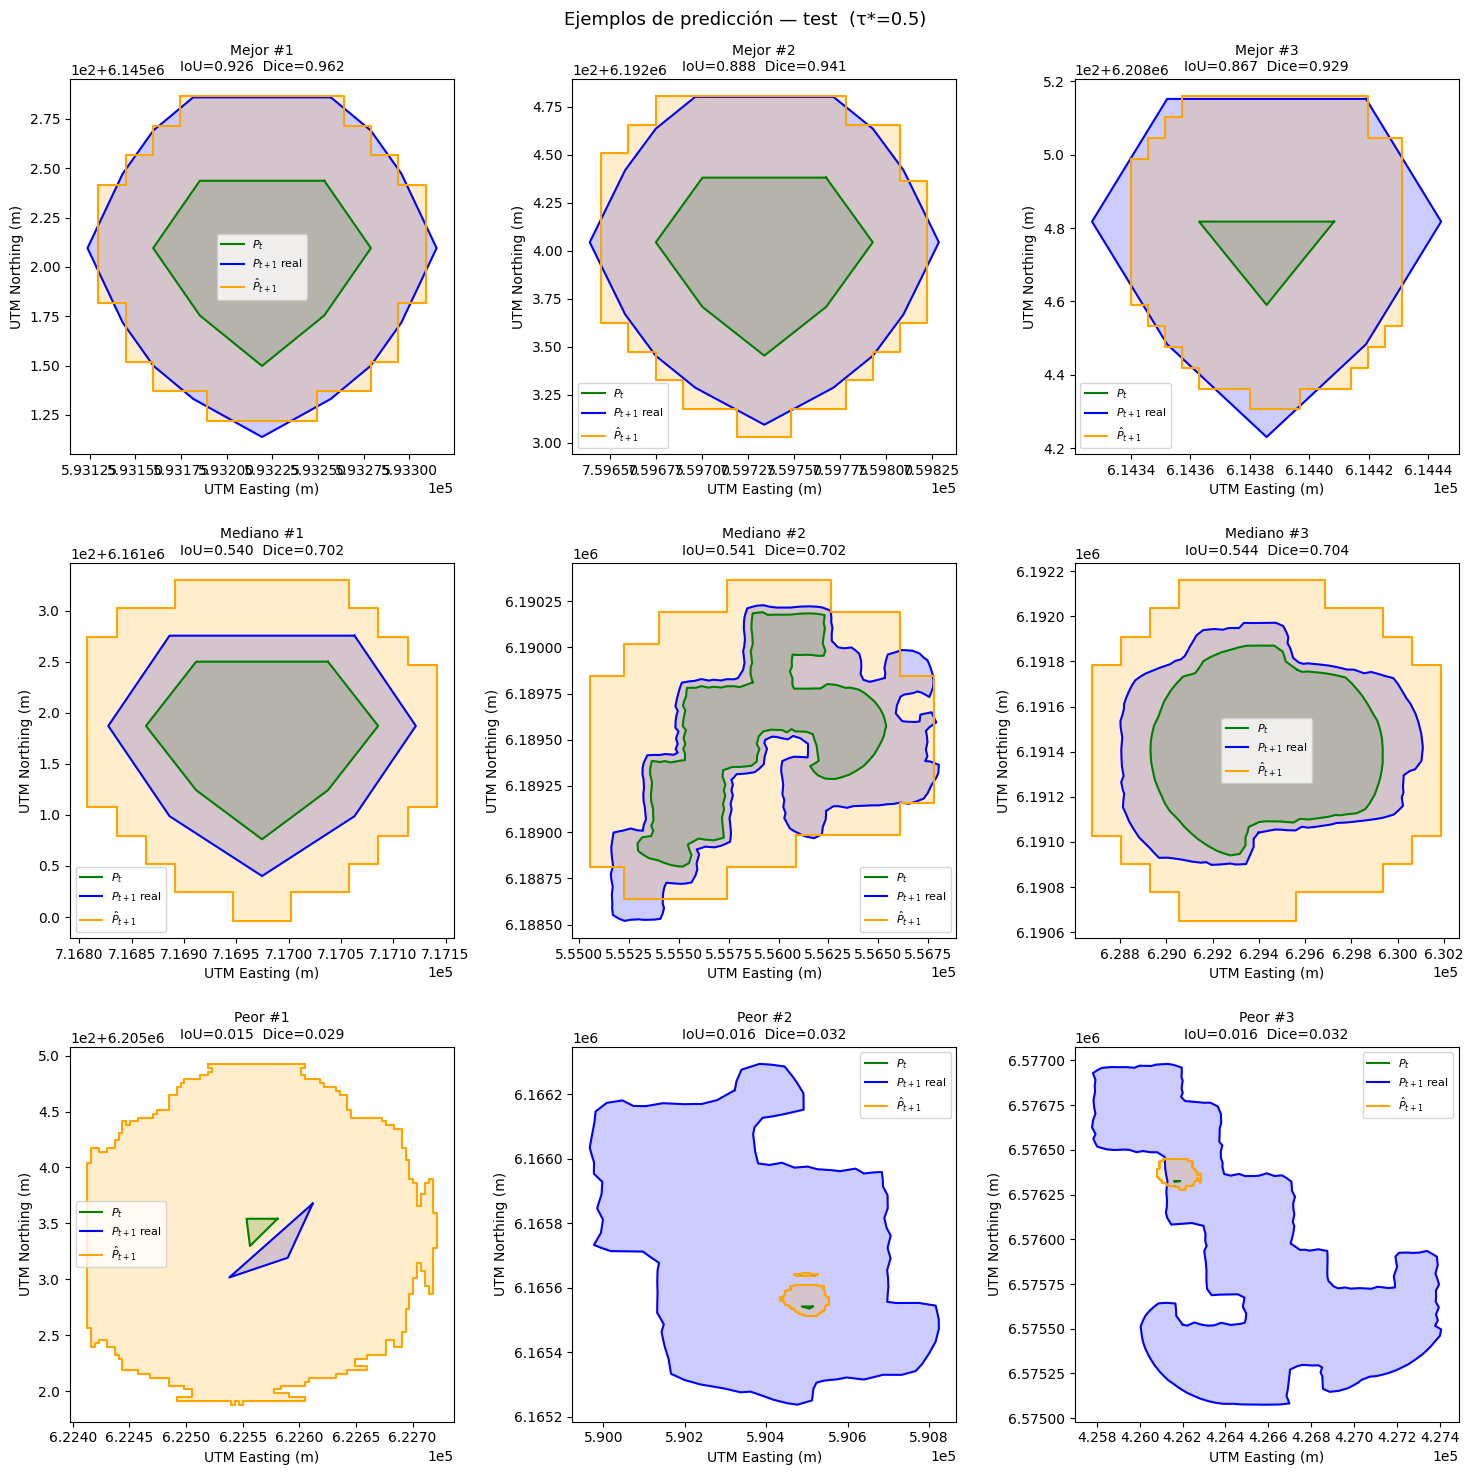

Figura guardada en outputs/qualitative_examples.png


In [14]:
def get_test_predictions(tau):
    """Devuelve lista de dicts con métricas por muestra (incluyendo errores geométricos)."""
    records = []
    model.eval()
    with torch.no_grad():
        for x, y, meta in test_loader:
            logits = model(x.to(DEVICE))
            probs  = torch.sigmoid(logits).cpu().numpy()

            for i in range(x.shape[0]):
                pred_mask = (probs[i, 0] >= tau).astype(np.uint8)
                transform = Affine.from_gdal(*meta[i]["transform"])

                polys = [
                    shape(g)
                    for g, v in rasterio.features.shapes(
                        pred_mask, mask=pred_mask, transform=transform
                    )
                    if int(v) == 1
                ]

                true_poly = polygonal_only(meta[i]["geom_t1"])
                geom_t    = meta[i].get("geom_t")

                if true_poly is None:
                    records.append({
                        "pt": geom_t, "pt1_true": None, "pt1_pred": None,
                        "poly_iou": 0.0, "poly_dice": 0.0,
                        "area_err_ha": np.nan, "centroid_disp_m": np.nan, "perim_err_m": np.nan,
                    })
                    continue

                fallback_disp = (
                    geom_t.centroid.distance(true_poly.centroid)
                    if geom_t is not None else np.nan
                )

                if not polys:
                    records.append({
                        "pt": geom_t, "pt1_true": true_poly, "pt1_pred": None,
                        "poly_iou": 0.0, "poly_dice": 0.0,
                        "area_err_ha": true_poly.area / 1e4,
                        "centroid_disp_m": fallback_disp,
                        "perim_err_m": true_poly.length,
                    })
                    continue

                pred_poly = polygonal_only(unary_union(polys))
                if pred_poly is None:
                    records.append({
                        "pt": geom_t, "pt1_true": true_poly, "pt1_pred": None,
                        "poly_iou": 0.0, "poly_dice": 0.0,
                        "area_err_ha": true_poly.area / 1e4,
                        "centroid_disp_m": fallback_disp,
                        "perim_err_m": true_poly.length,
                    })
                    continue

                records.append({
                    "pt":             geom_t,
                    "pt1_true":       true_poly,
                    "pt1_pred":       pred_poly,
                    "poly_iou":       poly_iou(pred_poly, true_poly),
                    "poly_dice":      poly_dice(pred_poly, true_poly),
                    "area_err_ha":     abs(pred_poly.area - true_poly.area) / 1e4,
                    "centroid_disp_m": pred_poly.centroid.distance(true_poly.centroid),
                    "perim_err_m":     abs(pred_poly.length - true_poly.length),
                })
    return records

test_records = get_test_predictions(TAU_STAR)
test_records_sorted = sorted(test_records, key=lambda r: r["poly_iou"])

n = len(test_records_sorted)
examples_by_type = {
    "Mejor":   [test_records_sorted[-1], test_records_sorted[-2], test_records_sorted[-3]],
    "Mediano": [test_records_sorted[n // 2 - 1], test_records_sorted[n // 2], test_records_sorted[n // 2 + 1]],
    "Peor":    [test_records_sorted[0], test_records_sorted[1], test_records_sorted[2]],
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, (type_label, recs) in enumerate(examples_by_type.items()):
    for col_idx, rec in enumerate(recs):
        ax = axes[row_idx, col_idx]
        for geom, color, name in [
            (rec["pt"],       "green",  r"$P_t$"),
            (rec["pt1_true"], "blue",   r"$P_{t+1}$ real"),
            (rec["pt1_pred"], "orange", r"$\hat{P}_{t+1}$"),
        ]:
            if geom is None or geom.is_empty:
                continue
            if geom.geom_type == "Polygon":
                geom_list = [geom]
            else:
                geom_list = [g for g in geom.geoms if hasattr(g, "exterior")]
            for g in geom_list:
                xs_g, ys_g = g.exterior.xy
                ax.fill(xs_g, ys_g, alpha=0.2, color=color)
                ax.plot(xs_g, ys_g, color=color, linewidth=1.5, label=name)

        ax.set_title(
            f"{type_label} #{col_idx + 1}\nIoU={rec['poly_iou']:.3f}  Dice={rec['poly_dice']:.3f}",
            fontsize=10,
        )
        ax.set_xlabel("UTM Easting (m)")
        ax.set_ylabel("UTM Northing (m)")
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8)
        ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

plt.suptitle(f"Ejemplos de predicción — test  (τ*={TAU_STAR})", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "qualitative_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada en outputs/qualitative_examples.png")

## 8. Análisis de distribución de métricas (test)

Media, mediana y percentiles de las métricas por muestra. Permite distinguir si los errores provienen de pocos casos catastróficos o son generalizados.

In [15]:
def summarize_records(records):
    def _stats(key):
        vals = np.array([r[key] for r in records
                         if key in r and not np.isnan(r[key])], dtype=float)
        if len(vals) == 0:
            return {}
        return {
            f"{key}_mean":   float(np.mean(vals)),
            f"{key}_median": float(np.median(vals)),
            f"{key}_p25":    float(np.quantile(vals, 0.25)),
            f"{key}_p75":    float(np.quantile(vals, 0.75)),
        }

    iou_vals = np.array([r["poly_iou"] for r in records])
    out = {
        "n_samples":           len(records),
        "iou_mean":            float(np.mean(iou_vals)),
        "iou_median":          float(np.median(iou_vals)),
        "iou_p25":             float(np.quantile(iou_vals, 0.25)),
        "iou_p75":             float(np.quantile(iou_vals, 0.75)),
        "pct_iou_lt_0_10":     float(np.mean(iou_vals < 0.10)),
        "pct_iou_gt_0_50":     float(np.mean(iou_vals > 0.50)),
    }
    for key in ("area_err_ha", "centroid_disp_m", "perim_err_m"):
        out.update(_stats(key))
    return out

dist = summarize_records(test_records)
print("Distribución de métricas por muestra — test:")
print(json.dumps({k: round(v, 4) for k, v in dist.items()}, indent=2))

json.dump(dist, open(OUTPUT_DIR / "test_distribution.json", "w"), indent=2)
print("\nGuardado en outputs/test_distribution.json")

Distribución de métricas por muestra — test:
{
  "n_samples": 187,
  "iou_mean": 0.4774,
  "iou_median": 0.5406,
  "iou_p25": 0.294,
  "iou_p75": 0.6572,
  "pct_iou_lt_0_10": 0.123,
  "pct_iou_gt_0_50": 0.5936,
  "area_err_ha_mean": 48.7278,
  "area_err_ha_median": 8.4341,
  "area_err_ha_p25": 1.1722,
  "area_err_ha_p75": 26.7721,
  "centroid_disp_m_mean": 89.1908,
  "centroid_disp_m_median": 51.7464,
  "centroid_disp_m_p25": 10.0186,
  "centroid_disp_m_p75": 100.3032,
  "perim_err_m_mean": 1807.1375,
  "perim_err_m_median": 475.0126,
  "perim_err_m_p25": 156.9481,
  "perim_err_m_p75": 1125.0976
}

Guardado en outputs/test_distribution.json
